# Storm and quiet-time identification

Builds two samples from the SYM-H storm catalog (`storm_list.csv`):

1. **100 storms**, stratified so the distribution of "number of storms in the following 60 days" matches the full catalog.
2. **100 quiet windows**, each 60 continuous days with no storm activity (no part of any storm between Initial Phase Start and Recovery Phase End), starting on unique UTC days.

In [46]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import datetime
import numpy as np
from tqdm.auto import tqdm

random_seed = 14

## 1. Storms following each storm

For each storm, find every storm whose main phase starts in the half-open interval (t, t + 60 days].

Since the main phase start times are sorted, the storms in any time interval form a contiguous block of rows. `np.searchsorted` returns the start (`lo`) and end (`hi`) row index of that block for every storm at once:
- `searchsorted(t, t, side='right')` gives the first row strictly **after** each storm, so the storm itself and any exact-timestamp ties are excluded.
- `searchsorted(t, t + 60d, side='right')` gives one past the last row at or before t + 60 days, so a storm at exactly +60 days is included.

So `df.iloc[lo[i]:hi[i]]` are the followers of storm `i`.

In [47]:
# The catalog is semicolon-delimited
storm_list = pd.read_csv('storm_list.csv', sep=';', parse_dates=['Main Phase Start'])
storm_list.drop('Storm Number', axis=1, inplace=True)
# searchsorted requires sorted input; it gives wrong results silently otherwise
df = storm_list.sort_values('Main Phase Start').reset_index(drop=True)

# For each storm, find the index range of storms whose main phase starts
# strictly after it and within the next 60 days: (t, t + 60d]
# Explicit datetime64 conversion: a plain .to_numpy() returns an object array
t = pd.to_datetime(df['Main Phase Start']).to_numpy(dtype='datetime64[ns]')
window = np.timedelta64(60, 'D')
lo = np.searchsorted(t, t, side='right')
hi = np.searchsorted(t, t + window, side='right')

Add the follow-up columns using the `lo:hi` slices from above:
- `n_storms_next_60d`: number of followers
- `mean_symh_next_60d`: mean Minimum SYM-H of the followers (NaN if there are none)
- `n_next_60d_<type>`: number of followers of each Classification

Storms in the last 60 days of the catalog have follow-up windows that run past the end of the data, so their counts are biased low. `df_full` drops them, and is used for sampling and statistics. `df` keeps all storms.

In [48]:
# Number of followers is just the length of each slice
df['n_storms_next_60d'] = hi - lo
# df['types_next_60d'] = [', '.join(df['Classification'].iloc[a:b]) for a, b in zip(lo, hi)]
# Empty slices (no followers) give NaN
df['mean_symh_next_60d'] = [df['Minimum SYM-H (nT)'].iloc[a:b].mean() for a, b in zip(lo, hi)]

# One value_counts per storm, stacked into a DataFrame with one column per type.
# index=df.index is needed: every value_counts Series is named 'count', so
# without it all rows would get the label 'count' and the join would fail.
# Storms with no followers give an all-NaN row, which fillna(0) turns into zeros.
type_counts = pd.DataFrame(
    [df['Classification'].iloc[a:b].value_counts() for a, b in zip(lo, hi)],
    index=df.index,
).fillna(0).astype(int).add_prefix('n_next_60d_')

df = df.join(type_counts)

# Drop storms whose 60-day window runs past the last storm in the catalog.
# Assumes the catalog's coverage ends at its last storm; if the underlying
# SYM-H data extends later, set catalog_end to the true coverage end instead.
catalog_end = df['Main Phase Start'].max()
cutoff = catalog_end - pd.Timedelta(days=60)

# Note: lo/hi index into df, not df_full. Any new lo/hi-based column must be
# computed on df first and then filtered.
df_full = df[df['Main Phase Start'] <= cutoff].reset_index(drop=True)


## 2. Distribution of follower counts and storm timeline

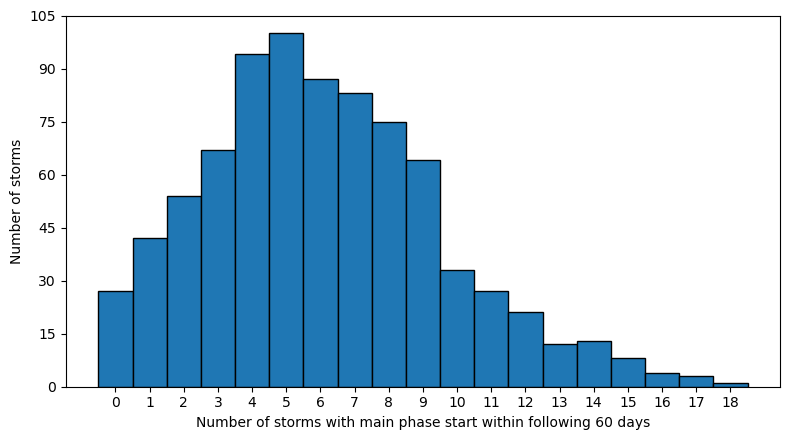

In [49]:
counts = df_full['n_storms_next_60d']

# Bin edges at half-integers so each bar is centered on an integer
bins = np.arange(counts.min(), counts.max() + 2) - 0.5

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(counts, bins=bins, edgecolor='black')

# One tick per integer value on x; integer-only ticks on y
ax.set_xticks(np.arange(counts.min(), counts.max() + 1))
ax.yaxis.set_major_locator(MaxNLocator(integer=True))

ax.set_xlabel('Number of storms with main phase start within following 60 days')
ax.set_ylabel('Number of storms')
plt.tight_layout()
plt.show()

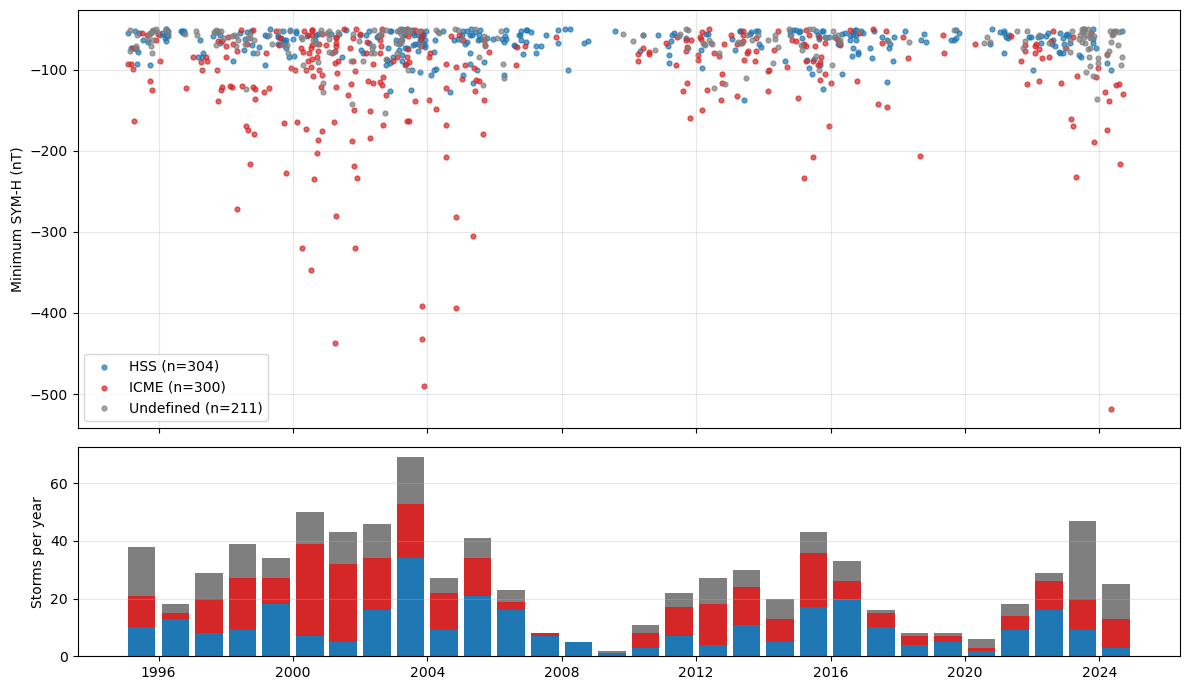

In [50]:
colors = {'HSS': 'tab:blue', 'ICME': 'tab:red', 'Undefined': 'tab:gray'}

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(12, 7), sharex=True, gridspec_kw={'height_ratios': [2, 1]}
)

# Top: each storm on the timeline
for cls, grp in df_full.groupby('Classification'):
    ax1.scatter(grp['Main Phase Start'], grp['Minimum SYM-H (nT)'],
                s=12, alpha=0.7, color=colors.get(cls), label=f'{cls} (n={len(grp)})')
ax1.set_ylabel('Minimum SYM-H (nT)')
ax1.legend(loc='lower left')
ax1.grid(alpha=0.3)

# Bottom: storms per year, stacked by classification.
# reindex so years with no storms appear as empty bars rather than being skipped
years = df_full['Main Phase Start'].dt.year
yearly = (pd.crosstab(years, df_full['Classification'])
            .reindex(range(years.min(), years.max() + 1), fill_value=0))
x = pd.to_datetime(yearly.index.astype(str) + '-07-01')  # center bars mid-year

# Stack bars by accumulating each type's counts into the next type's baseline
bottom = np.zeros(len(yearly))
for cls in yearly.columns:
    ax2.bar(x, yearly[cls], width=300, bottom=bottom, color=colors.get(cls), label=cls)
    bottom += yearly[cls].to_numpy()
ax2.set_ylabel('Storms per year')
ax2.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 3. Stratified sample of storms

Proportional stratified sampling on `n_storms_next_60d`: each follower count gets a share of the 100 storms equal to its share of `df_full`, then storms are drawn at random.

Follow-up windows of the selected storms can overlap each other.

In [51]:
n_sample = 100
strata = df_full['n_storms_next_60d']

# Target number of storms per follower count, proportional to the full set
props = strata.value_counts().sort_index() / len(strata)
exact = props * n_sample

# Round down, then give the leftover slots to the largest fractional remainders
# so the total is exactly n_sample (largest-remainder method)
alloc = np.floor(exact).astype(int)
# print(alloc)
remainder = n_sample - alloc.sum()
alloc[(exact - alloc).sort_values(ascending=False).index[:remainder]] += 1
# Draw within each stratum without replacement. A single seeded Generator is
# passed through so the whole sample is reproducible.
rng = np.random.default_rng(random_seed)
sample = pd.concat([
    df_full[strata == n].sample(n=k, random_state=rng)
    for n, k in alloc.items() if k > 0
]).sort_values('Main Phase Start')

## 4. Quiet gaps between storms

In [60]:
# Re-read with the other phase columns parsed (df only parsed Main Phase Start)
storms = pd.read_csv('storm_list.csv', sep=';',
                     parse_dates=['Initial Phase Start', 'Recovery Phase End'])
storms = storms.sort_values('Initial Phase Start').reset_index(drop=True)

# Merge overlapping storms into continuous active blocks.
# A new block starts when a storm begins after every earlier storm has ended.
# The running maximum of end times matters: a long storm can outlast several
# shorter storms that start after it, so comparing only to the previous storm
# isn't enough.
st = storms['Initial Phase Start'].to_numpy(dtype='datetime64[ns]')
en = storms['Recovery Phase End'].to_numpy(dtype='datetime64[ns]')
running_end = np.maximum.accumulate(en)
block_id = np.cumsum(np.r_[True, st[1:] > running_end[:-1]])

blocks = (pd.DataFrame({'start': st, 'end': en, 'block': block_id})
            .groupby('block').agg(start=('start', 'min'), end=('end', 'max')))

# Gaps are between the end of one block and the start of the next
gaps = pd.DataFrame({
    'gap_start': blocks['end'].to_numpy()[:-1],
    'gap_end':   blocks['start'].to_numpy()[1:],
})
gaps['duration'] = gaps['gap_end'] - gaps['gap_start']

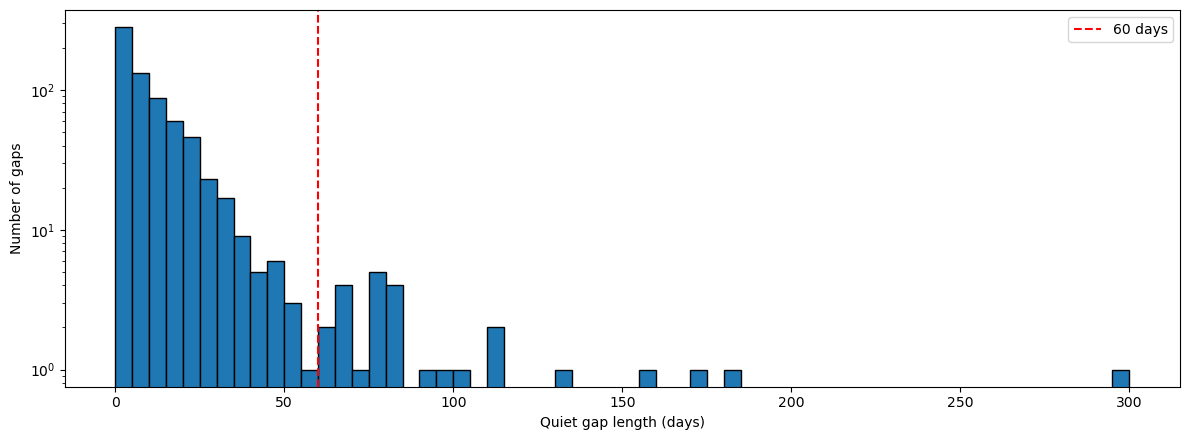

In [53]:
gap_days = gaps['duration'].dt.total_seconds() / 86400

fig, ax1 = plt.subplots(1, 1, figsize=(12, 4.5))

# Log count axis: the distribution is heavily skewed toward short gaps
ax1.hist(gap_days, bins=np.arange(0, gap_days.max() + 5, 5), edgecolor='black')
ax1.set_yscale('log')
ax1.set_xlabel('Quiet gap length (days)')
ax1.set_ylabel('Number of gaps')

ax1.axvline(60, color='red', ls='--', label='60 days')
ax1.legend()
plt.tight_layout()
plt.show()

## 5. Sample of quiet 60-day windows

Each window is 60 continuous days entirely inside one quiet gap. Windows may overlap and may share a gap, but each starts on a unique UTC calendar day.

In [ ]:
window = pd.Timedelta(days=60)
valid = gaps[gaps['duration'] >= window].copy()
# A window starting after latest_start would run into the next storm
valid['latest_start'] = valid['gap_end'] - window

# Every calendar day containing at least one valid start time,
# with the portion of that day where a window can start.
# Consecutive gaps' valid ranges are >= 60 days apart, so each day appears once.
# (day_lo/day_hi rather than lo/hi so the section 1 arrays aren't overwritten)
rows = []
for gap_id, g in tqdm(valid.iterrows(), total=len(valid), desc='Listing valid start days per gap'):
    for day in pd.date_range(g['gap_start'].floor('D'), g['latest_start'].floor('D'), freq='D'):
        day_lo = max(day, g['gap_start'])
        day_hi = min(day + pd.Timedelta(days=1), g['latest_start'])
        if day_hi > day_lo:
            rows.append((day, gap_id, day_lo, day_hi))
days = pd.DataFrame(rows, columns=['day', 'gap_id', 'range_start', 'range_end'])

# Pick distinct days, weighted by how much of each day is valid.
# replace=False on days is what guarantees unique start days.
w = (days['range_end'] - days['range_start']).dt.total_seconds().to_numpy()
rng = np.random.default_rng(random_seed)
pick = days.iloc[rng.choice(len(days), size=100, replace=False, p=w / w.sum())].copy()

# Uniform start time within each chosen day's valid range. Gap boundaries are on
# whole minutes, so flooring to the minute can't move a start outside its range.
frac = rng.uniform(0, 1, len(pick))
pick['window_start'] = (pick['range_start']
                        + (pick['range_end'] - pick['range_start']) * frac).dt.floor('min')

quiet = pick[['window_start', 'gap_id']].sort_values('window_start').reset_index(drop=True)
quiet['window_end'] = quiet['window_start'] + window

Listing valid start days per gap:   0%|          | 0/26 [00:00<?, ?it/s]

In [55]:
print(quiet['window_start'].dt.normalize().is_unique)   # True: unique start days
# Interval intersection test: a storm [Initial, Recovery] touches a window [s, e]
# if it starts before the window ends and ends after the window starts
overlaps = [((storms['Initial Phase Start'] <= e) & (storms['Recovery Phase End'] >= s)).any()
            for s, e in zip(quiet['window_start'], quiet['window_end'])]
print(sum(overlaps))                                     # 0: no window touches a storm

True
0


## 6. Plots of the selected storms and quiet windows

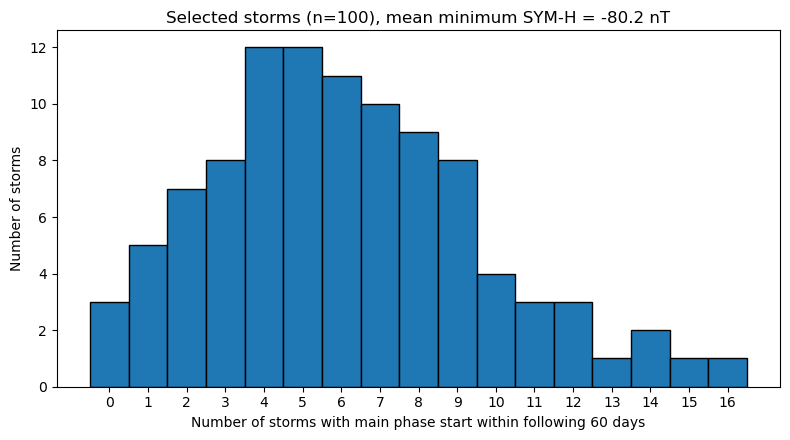

In [56]:
counts = sample['n_storms_next_60d']
# Mean of the selected storms' own minimum SYM-H
mean_symh = sample['Minimum SYM-H (nT)'].mean()
bins = np.arange(counts.min(), counts.max() + 2) - 0.5

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(counts, bins=bins, edgecolor='black')
ax.set_xticks(np.arange(counts.min(), counts.max() + 1))
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
ax.set_xlabel('Number of storms with main phase start within following 60 days')
ax.set_ylabel('Number of storms')
ax.set_title(f'Selected storms (n={len(sample)}), mean minimum SYM-H = {mean_symh:.1f} nT')
plt.tight_layout()
plt.show()

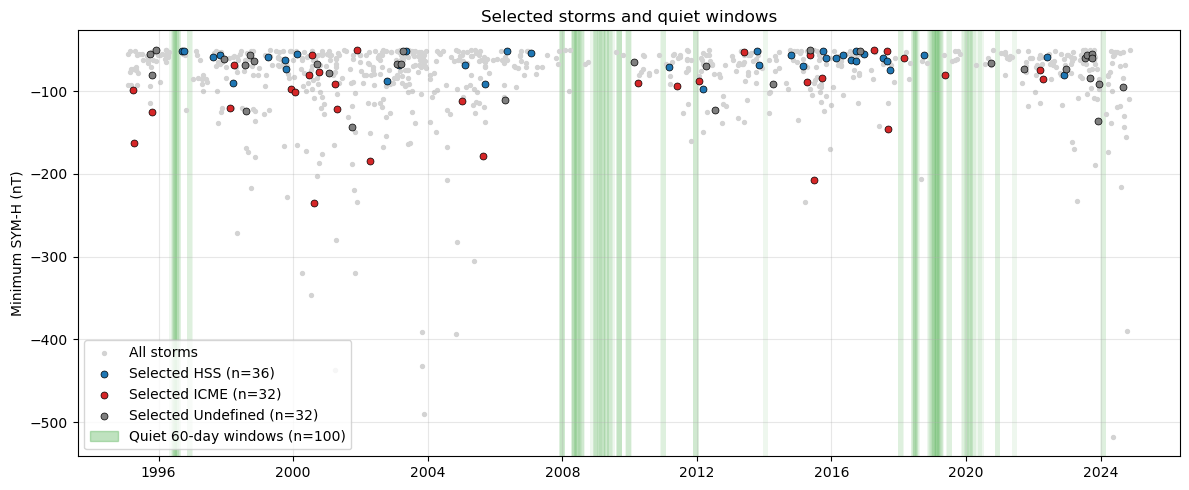

In [57]:
from matplotlib.patches import Patch

colors = {'HSS': 'tab:blue', 'ICME': 'tab:red', 'Undefined': 'tab:gray'}

fig, ax = plt.subplots(figsize=(12, 5))

# Quiet windows shaded in the background (darker where windows overlap)
for s, e in zip(quiet['window_start'], quiet['window_end']):
    ax.axvspan(s, e, color='tab:green', alpha=0.08, lw=0, zorder=0)

# Full catalog, then selected storms on top
ax.scatter(df['Main Phase Start'], df['Minimum SYM-H (nT)'],
           s=8, color='lightgray', label='All storms', zorder=1)
for cls, grp in sample.groupby('Classification'):
    ax.scatter(grp['Main Phase Start'], grp['Minimum SYM-H (nT)'], s=25,
               color=colors.get(cls), edgecolor='black', linewidth=0.5,
               label=f'Selected {cls} (n={len(grp)})', zorder=2)

# axvspan doesn't add a legend entry per span, so add one proxy patch
handles, labels = ax.get_legend_handles_labels()
handles.append(Patch(color='tab:green', alpha=0.3))
labels.append(f'Quiet 60-day windows (n={len(quiet)})')
ax.legend(handles, labels, loc='lower left')

ax.set_ylabel('Minimum SYM-H (nT)')
ax.set_title('Selected storms and quiet windows')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Save outputs

Semicolon-delimited to match `storm_list.csv`.
- `selected_storms_100.csv`: the 100 sampled storms, with all catalog and follow-up columns
- `selected_quiet_windows_100.csv`: the 100 quiet windows (start, end, and source gap id)
- `storm_list_with_60d_columns.csv`: the full catalog (all storms, including the last 60 days) with the follow-up columns added. Follow-up counts for storms after `cutoff` are truncated by the end of the catalog.

In [58]:
sample.to_csv('selected_storms_100.csv', sep=',', index=False)
quiet[['window_start', 'window_end']].to_csv(
    'selected_quiet_windows_100.csv', sep=',', index=False)
df.to_csv('storm_list_with_60d_columns.csv', sep=',', index=False)

print(f'Saved {len(sample)} storms, {len(quiet)} quiet windows, {len(df)} catalog rows')

Saved 100 storms, 100 quiet windows, 821 catalog rows
